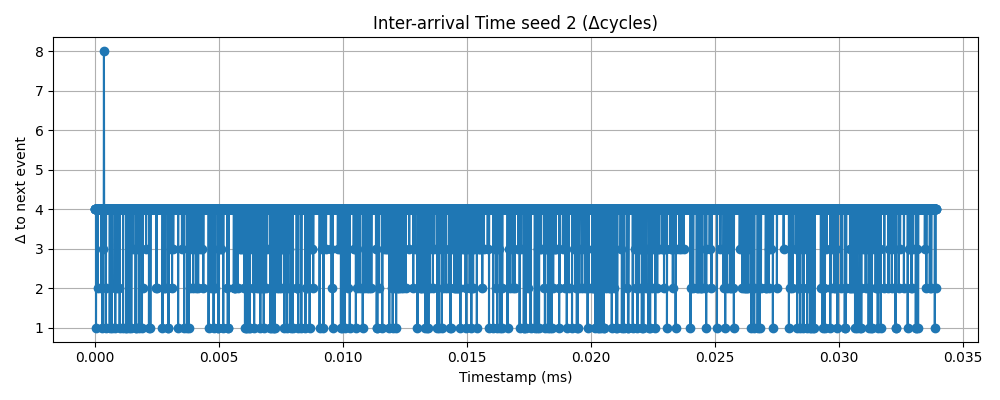

In [8]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("graphs/nmu_01_AXIS_receiver.csv")

# Compute delta between consecutive ms values
df["delta_ms"] = df["ms"].diff()*1e6

# Drop the first row (NaN delta)
df = df.dropna()

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df["ms"], df["delta_ms"], marker='o')
plt.xlabel("Timestamp (ms)")
plt.ylabel("Δ to next event")
plt.title("Inter-arrival Time seed 2 (Δcycles)")
plt.grid(True)
plt.tight_layout()
plt.show()

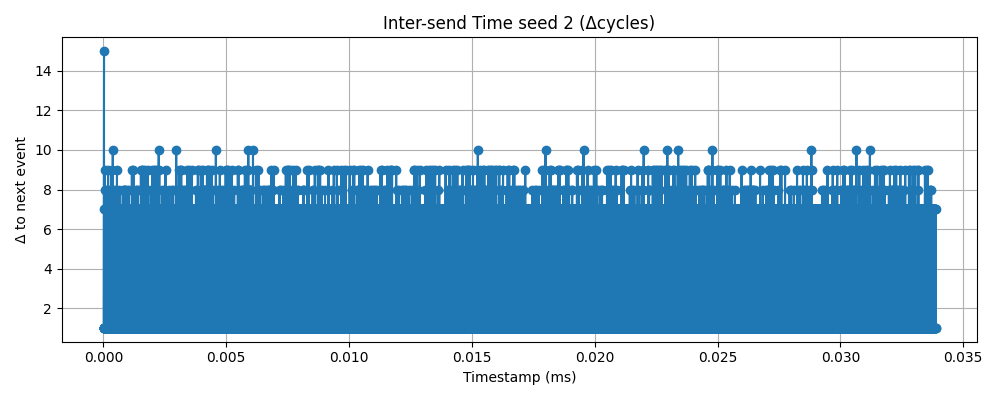

In [9]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("graphs/nmu_01_AXIS_sender.csv")

# Compute delta between consecutive ms values
df["delta_ms"] = df["ms"].diff()*1e6

# Drop the first row (NaN delta)
df = df.dropna()

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df["ms"], df["delta_ms"], marker='o')
plt.xlabel("Timestamp (ms)")
plt.ylabel("Δ to next event")
plt.title("Inter-send Time seed 2 (Δcycles)")
plt.grid(True)
plt.tight_layout()
plt.show()

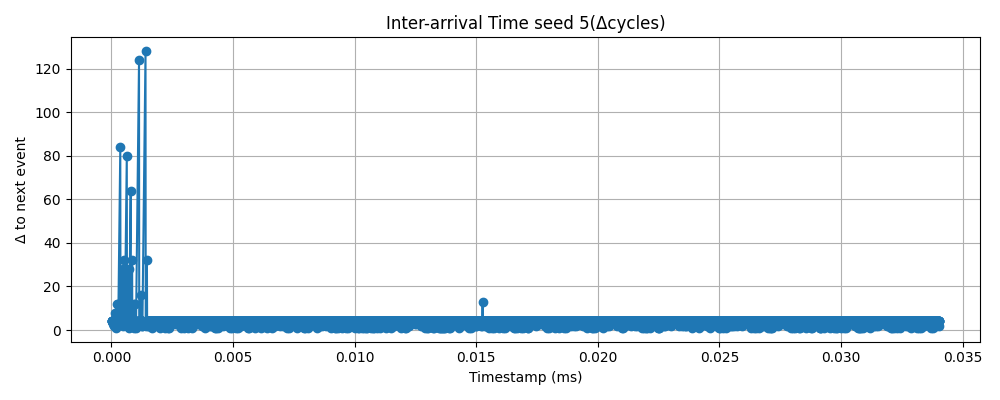

In [3]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("graphs/nmu_01_AXIS_receiver.csv")

# Compute delta between consecutive ms values
df["delta_ms"] = df["ms"].diff()*1e6

# Drop the first row (NaN delta)
df = df.dropna()

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df["ms"], df["delta_ms"], marker='o')
plt.xlabel("Timestamp (ms)")
plt.ylabel("Δ to next event")
plt.title("Inter-arrival Time seed 5(Δcycles)")
plt.grid(True)
plt.tight_layout()
plt.show()

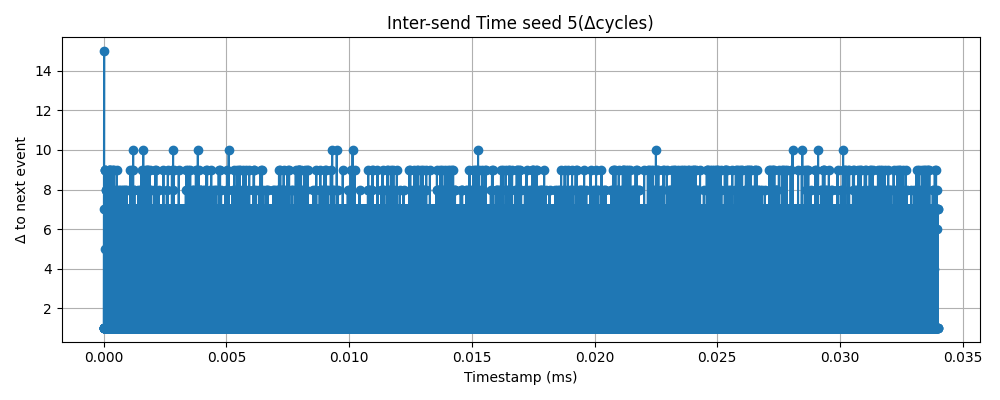

In [4]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("graphs/nmu_01_AXIS_sender.csv")

# Compute delta between consecutive ms values
df["delta_ms"] = df["ms"].diff()*1e6

# Drop the first row (NaN delta)
df = df.dropna()

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df["ms"], df["delta_ms"], marker='o')
plt.xlabel("Timestamp (ms)")
plt.ylabel("Δ to next event")
plt.title("Inter-send Time seed 5(Δcycles)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

sender = pd.read_csv("graphs/nmu_02_AXIS_sender.csv")
print( f"tlasts from sender: { len(sender[sender['end']==1]) }" )

receiver = pd.read_csv("graphs/nmu_02_AXIS_receiver.csv")
print( f"tlasts from receiver: {len(receiver[receiver['end']==1])}" )


tlasts from sender: 1000
tlasts from receiver: 1000


In [5]:
# mismatch = sender[sender['end']==1]["num_bytes"].reset_index(drop=True) != receiver[receiver['end']==1]["num_bytes"].reset_index(drop=True)
# print(mismatch)
print(sender[sender['end']==1]["num_bytes"])
print(receiver[receiver['end']==1]["num_bytes"])

22      60
23      60
25       6
27      37
48      53
        ..
8091    36
8095    26
8097    24
8121    38
8124    14
Name: num_bytes, Length: 512, dtype: int64
22      60
23      60
25       6
27      37
48      53
        ..
8089    14
8091    36
8095    26
8097    24
8121    38
Name: num_bytes, Length: 511, dtype: int64


In [29]:
import pandas as pd


# Ensure time order (just in case)
sender = sender.sort_values("ms").reset_index(drop=True)

# Create a group id that increments every time end == 1
sender["packet_id"] = sender["end"].shift(fill_value=0).cumsum()

# Sum num_bytes per packet
packet_bytes = (
    sender.groupby("packet_id", as_index=False)
      .agg(
          start_ms=("ms", "first"),
          end_ms=("ms", "last"),
          total_bytes=("num_bytes", "sum")
      )
)

print(packet_bytes)

     packet_id  start_ms    end_ms  total_bytes
0            0  0.000000  0.000331          663
1            1  0.000332  0.001009         1355
2            2  0.001010  0.001426          834
3            3  0.001427  0.001773          694
4            4  0.001774  0.002477         1408
..         ...       ...       ...          ...
995        995  0.383892  0.384061          340
996        996  0.384062  0.384782         1442
997        997  0.384783  0.385157          750
998        998  0.385158  0.385573          831
999        999  0.385574  0.385574            2

[1000 rows x 4 columns]


In [30]:
import pandas as pd


# Ensure time order (just in case)
receiver = receiver.sort_values("ms").reset_index(drop=True)

# Create a group id that increments every time end == 1
receiver["packet_id"] = receiver["end"].shift(fill_value=0).cumsum()

# Sum num_bytes per packet
packet_bytes = (
    receiver.groupby("packet_id", as_index=False)
      .agg(
          start_ms=("ms", "first"),
          end_ms=("ms", "last"),
          total_bytes=("num_bytes", "sum")
      )
)

print(packet_bytes)

     packet_id  start_ms    end_ms  total_bytes
0            0  0.000146  0.000356          663
1            1  0.000478  0.001029         1355
2            2  0.001156  0.001446          834
3            3  0.001573  0.001800          694
4            4  0.001920  0.002500         1408
..         ...       ...       ...          ...
994        994  0.383699  0.383917          677
995        995  0.384038  0.384082          340
996        996  0.384208  0.384808         1442
997        997  0.384929  0.385187          750
998        998  0.385304  0.385572          768

[999 rows x 4 columns]
